# 02 — KNN Baseline (wszystkie 55 cech)

**Cel**: Ustalenie baseline — KNN (k=5) na wszystkich 55 cechach, bez selekcji.
Wynik stanowi punkt odniesienia dla algorytmów selekcji cech (EWOA, WOA).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

from src.data.loader import load_raw_data, preprocess, make_splits
from src.evaluation.visualization import plot_confusion_matrix
from src.utils.config import SEED

np.random.seed(SEED)

## 1. Ładowanie danych

In [2]:
df = load_raw_data()
X, y = preprocess(df, mode='binary')
X_train, X_test, y_train, y_test = make_splits(X, y)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Wczytano 58058 wierszy z 1 pliku/plików.
Kolumny (57): ['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit'] ...
  58058 próbek | 55 cech | tryb: binary
  Rozkład klas: {'Benign': 29227, 'Malware': 28831}
  Split: train=46446, test=11612
X_train: (46446, 55), X_test: (11612, 55)


## 2. KNN na wszystkich 55 cechach

In [3]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'\nAccuracy (55 cech): {acc:.5f}')
print()
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))


Accuracy (55 cech): 0.99991

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5846
     Malware       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612



## 3. Confusion Matrix

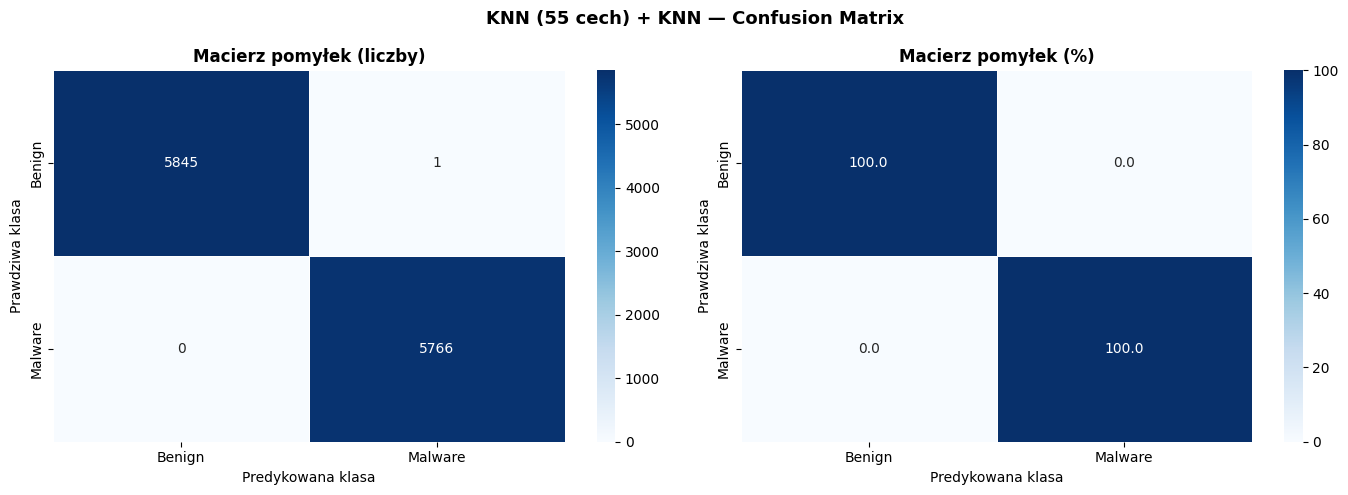

In [4]:
plot_confusion_matrix(y_test, y_pred, algorithm_name='KNN (55 cech)', save_name='confusion_baseline')

## 4. Wpływ k na accuracy

k= 1  →  accuracy = 1.00000


k= 3  →  accuracy = 0.99991


k= 5  →  accuracy = 0.99991


k= 7  →  accuracy = 0.99991


k= 9  →  accuracy = 0.99983


k=11  →  accuracy = 0.99974


k=15  →  accuracy = 0.99974


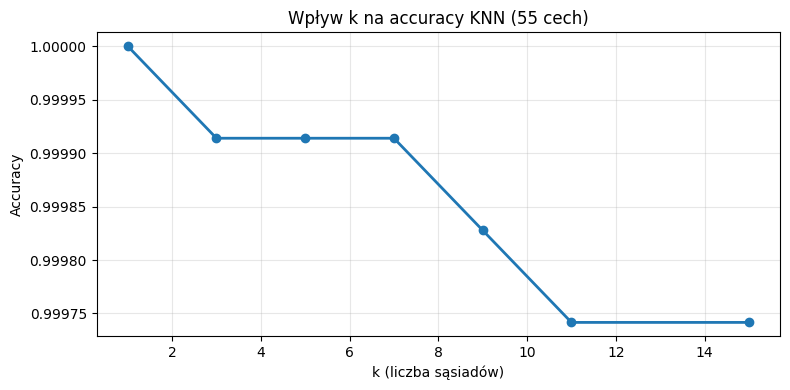

In [5]:
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    acc_k = accuracy_score(y_test, knn_k.predict(X_test))
    accuracies.append(acc_k)
    print(f'k={k:2d}  →  accuracy = {acc_k:.5f}')

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, 'o-', linewidth=2)
plt.xlabel('k (liczba sąsiadów)')
plt.ylabel('Accuracy')
plt.title('Wpływ k na accuracy KNN (55 cech)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/knn_k_vs_accuracy.png', dpi=150)
plt.show()

## Podsumowanie

KNN z k=5 na **wszystkich 55 cechach** daje wysoki accuracy.
Celem EWOA jest osiągnięcie **porównywalnego accuracy przy ~4 cechach** (zamiast 55).